In [ ]:
pip install rouge-score pandas matplotlib seaborn

  Using cached rouge_score-0.1.2.tar.gz (17 kB)
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'rouge-score' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'rouge-score'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24988 sha256=67056f24e770a99581018433e2c15830dac1aa6d708cab32e574eb1cc6310dab
  Stored in directory: /Users/senudaliyanage/Library/Caches/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge-score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [rouge-score]
Note: you may need to restart the kernel to use updated packa

In [2]:
import os
import pandas as pd
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
reference_dir = "/Users/senudaliyanage/Downloads/IIT/Final Year Project/Legal Document Summarization/results/openai_results/openai_summaries_test_merged"
model_dir = "/Users/senudaliyanage/Downloads/IIT/Final Year Project/Legal Document Summarization/results/mistral32B_results/mistral24B_summaries_test_merged"


In [4]:
scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

In [5]:
results = []

for file in os.listdir(reference_dir):

    if not file.endswith(".txt"):
        continue
        
    ref_path = os.path.join(reference_dir, file)
    model_path = os.path.join(model_dir, file)

    if not os.path.exists(model_path):
        continue

    with open(ref_path) as f:
        reference = f.read()

    with open(model_path) as f:
        prediction = f.read()

    scores = scorer.score(reference, prediction)

    results.append({
        "document": file,
        "rouge1": scores["rouge1"].fmeasure,
        "rouge2": scores["rouge2"].fmeasure,
        "rougeL": scores["rougeL"].fmeasure
    })

df = pd.DataFrame(results)

df.head()

,document,rouge1,rouge2,rougeL
0,2019-08-20-56.txt,0.437209,0.225352,0.325581
1,2017-08-08-223.txt,0.489583,0.283925,0.345833
2,2015-09-22-78.txt,0.427481,0.229885,0.267176
3,2007-02-09-05.txt,0.400000,0.224666,0.304314
4,2013-03-08-08.txt,0.557545,0.431877,0.398977


In [6]:
mean_scores = df[["rouge1","rouge2","rougeL"]].mean()

print("Mean ROUGE scores:")
print(mean_scores)

Mean ROUGE scores:
rouge1    0.546347
rouge2    0.298827
rougeL    0.357794
dtype: float64


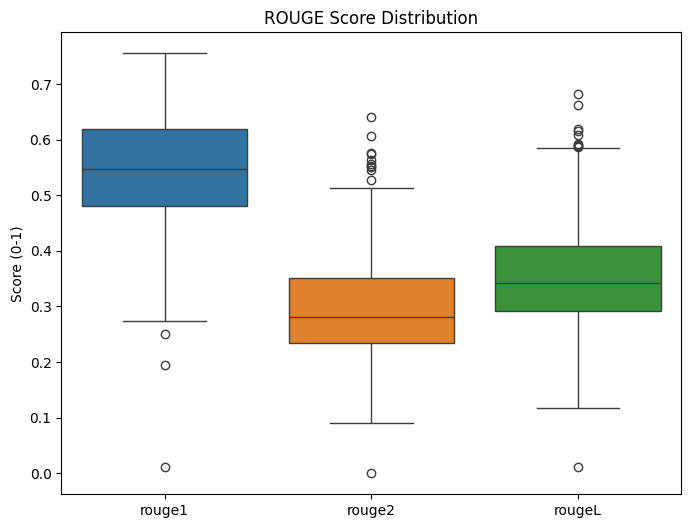

In [7]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df[["rouge1","rouge2","rougeL"]])

plt.title("ROUGE Score Distribution")
plt.ylabel("Score (0-1)")
plt.show()

In [8]:
score_cols = ["rouge1", "rouge2", "rougeL"]

Q1 = df[score_cols].quantile(0.25)
Q3 = df[score_cols].quantile(0.75)

IQR = Q3 - Q1

In [9]:
df_clean = df[~(
    (df[score_cols] < (Q1 - 1.5 * IQR)) |
    (df[score_cols] > (Q3 + 1.5 * IQR))
).any(axis=1)]

In [10]:
df_clean[score_cols].mean()

rouge1    0.542852
rouge2    0.291002
rougeL    0.350825
dtype: float64

In [11]:
print("Original docs:", len(df))
print("After outlier removal:", len(df_clean))

Original docs: 373
After outlier removal: 356
